In [1]:
!pip install dynesty


In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
import corner 
import dynesty 
from scipy.stats import norm
import emcee



C:\Users\user\AppData\Local\Temp\ipykernel_9464\1723553249.py:22: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and 0 < t0 < 100 and -5 < np.log(alpha) < 5:


Median: [10.30584837  5.59704983 49.05750708  0.12816981]
90% Credible Region: [[10.15167463  3.99060548 47.25392378  0.0974139 ]
 [10.46003461  8.25754447 51.45744312  0.16950409]]


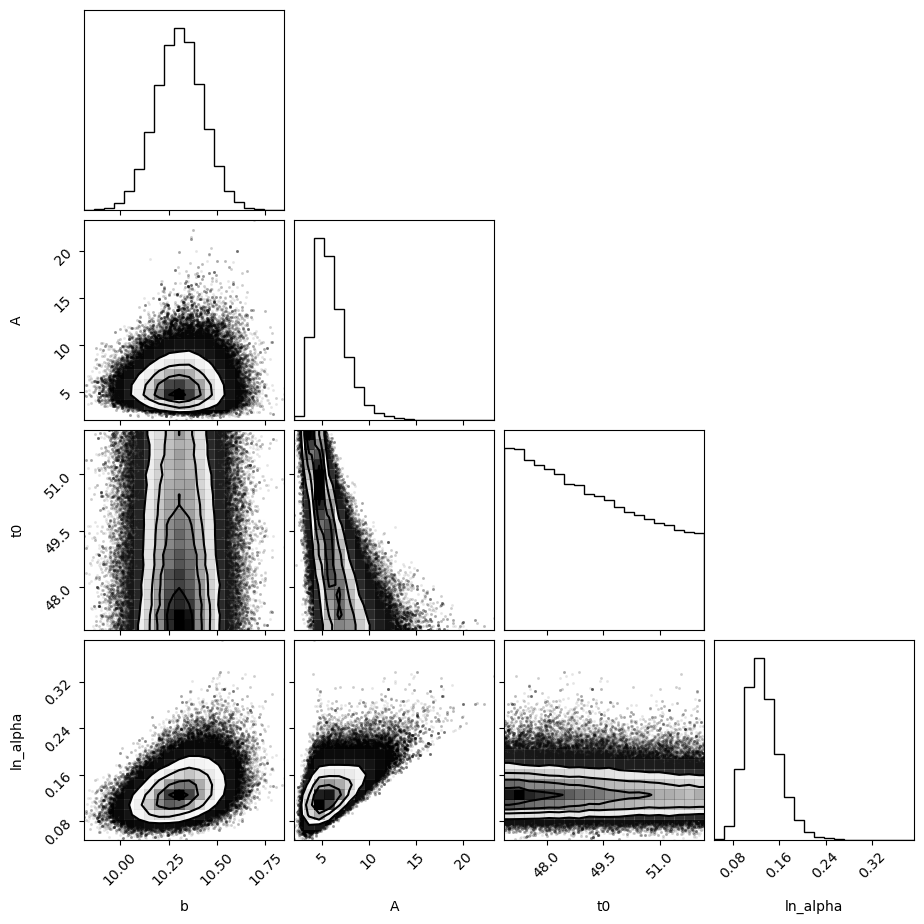

In [15]:
#L12 exercise 
#Lets do the same as before but with dynesty 


# Load the data
data = np.load('C:/Users/user/Desktop/astrostatistics_bicocca_2026/solutions/transient.npy')
t, flux, unc = data[:,0], data[:,1], data[:,2]

# Define the model
def burst_model(t, b, A, t0, alpha):
    return b + A * np.exp(-alpha * (t - t0)) * (t >= t0)

# Define the log-likelihood function
def log_likelihood(theta, x, y, yerr):
    b, A, t0, alpha = theta
    model = burst_model(x, b, A, t0, alpha)
    return -0.5 * np.sum(((y - model) / yerr) ** 2)

# Define the log-prior function
def log_prior(theta):
    b, A, t0, alpha = theta
    if 0 < b < 50 and 0 < A < 50 and 0 < t0 < 100 and -5 < np.log(alpha) < 5:
        return 0.0
    return -np.inf

# Define the log-posterior function
def log_posterior(theta, x, y, yerr):
    return log_prior(theta) + log_likelihood(theta, x, y, yerr)

# Initial guess
initial_guess = [10, 10, 50, 0.1]

# Run emcee
n_walkers = 50
n_dim = 4
n_samples = 10000

pos = initial_guess + 1e-4 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(t, flux, unc))
sampler.run_mcmc(pos, n_samples)

# Get posterior samples
posterior_samples = sampler.get_chain(discard=1000, flat=True)

# Calculate median and 90% credible region
median = np.median(posterior_samples, axis=0)
cri = np.percentile(posterior_samples, [10, 90], axis=0)

# Print results
print("Median:", median)
print("90% Credible Region:", cri)

corner.corner(posterior_samples, labels=["b", "A", "t0", "ln_alpha"])
plt.show()


In [18]:
#now lets fit the same model from before with the same priors, but this time use nested sampling.
#we need to define the prior transform function, which transforms the unit hypercube to the parameter space we will use ppf from scipy.stats.
# An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

from scipy import stats

data = np.load('solutions/transient.npy')
t = data[:,0]
y = data[:,1]
yerr = data[:,2]

logl_args = [t, y, yerr]

ndim = 4

def prior_transform(u):
    b = stats.uniform.ppf(u[0], 0, 50)
    A = stats.uniform.ppf(u[1], 0, 50)
    t0 = stats.uniform.ppf(u[2], 0, 100)
    ln_alpha = stats.uniform.ppf(u[3], -5, 10)
    return np.array([b, A, t0, ln_alpha])

#now we can use dynesty to sample from the posterior.

sampler = dynesty.NestedSampler(log_likelihood, prior_transform, ndim, logl_args=logl_args)
sampler.run_nested()
sresults = sampler.results









C:\Users\user\AppData\Local\Temp\ipykernel_9464\1723553249.py:17: RuntimeWarning: overflow encountered in square
  return -0.5 * np.sum(((y - model) / yerr) ** 2)
c:\Users\user\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
1834it [00:29, 10.28it/s, bound: 1 | nc: 25 | ncall: 18382 | eff(%):  9.977 | loglstar:   -inf < -256.712 <    inf | logz: -265.782 +/-    nan | dlogz: 184.427 >  0.509]      C:\Users\user\AppData\Local\Temp\ipykernel_9464\1723553249.py:17: RuntimeWarning: overflow encountered in square
  return -0.5 * np.sum(((y - model) / yerr) ** 2)
1890it [00:32, 15.91it/s, bound: 2 | nc: 59 | ncall: 19053 | eff(%):  9.920 | loglstar:   -inf < -234.131 <    inf | logz: -243.054 +/-    nan | dlogz: 161.490 >  0.509]C:\Users\user\AppData\Local\Temp\ipykernel_9464\1723553249.py:17: RuntimeWarning: overflow encountered in square
  return -0.5 * np.sum(((y - model) / y

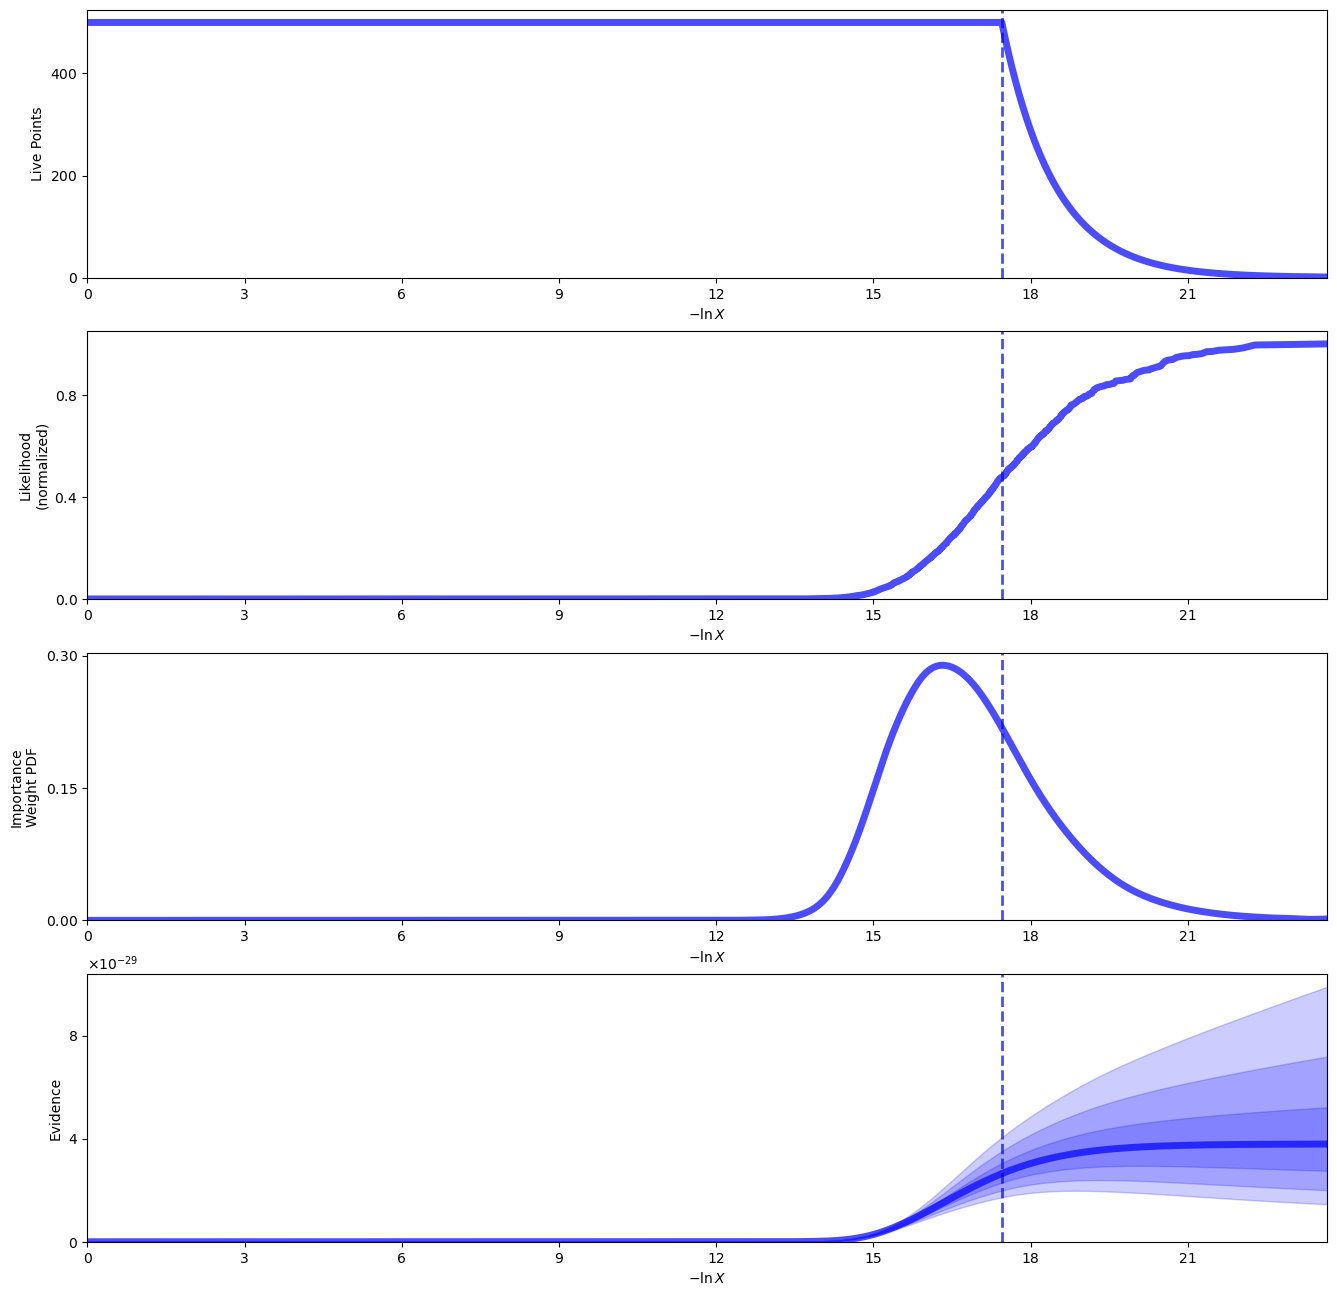

In [19]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

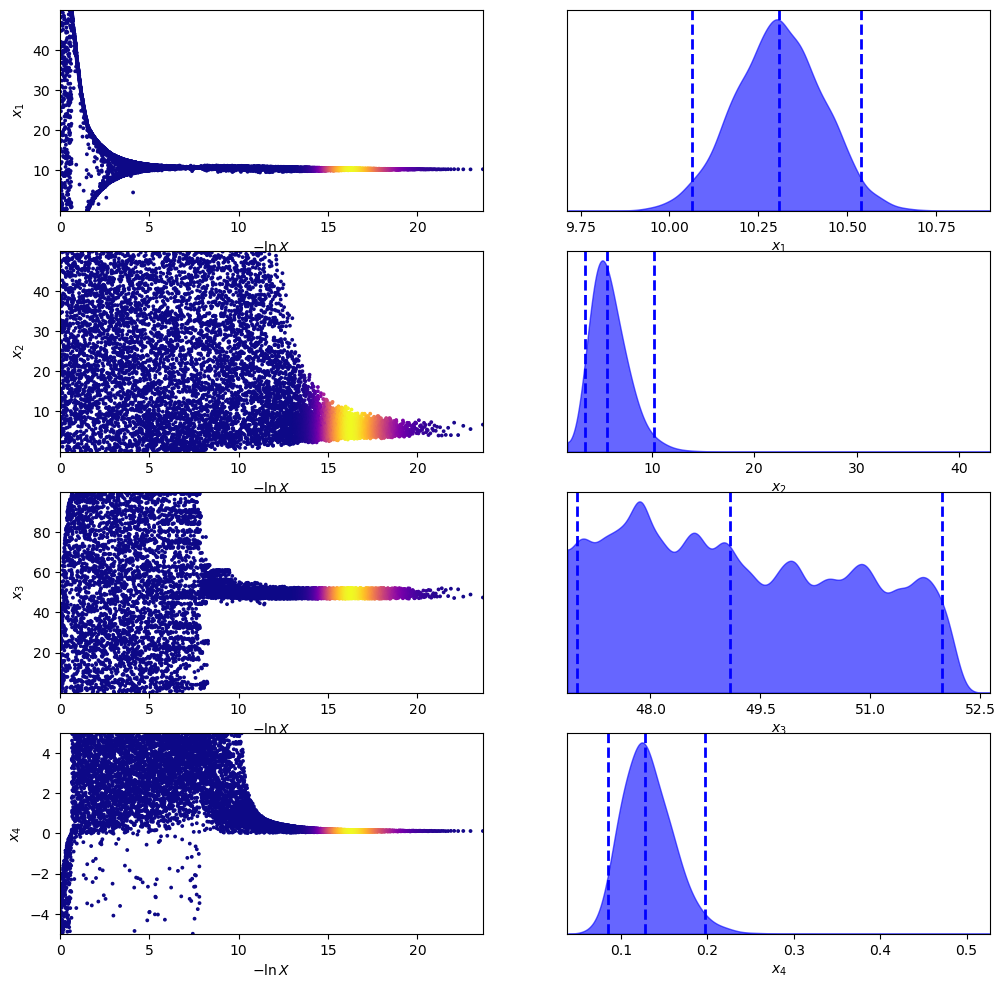

In [20]:
tfig, taxes = dyplot.traceplot(sresults)

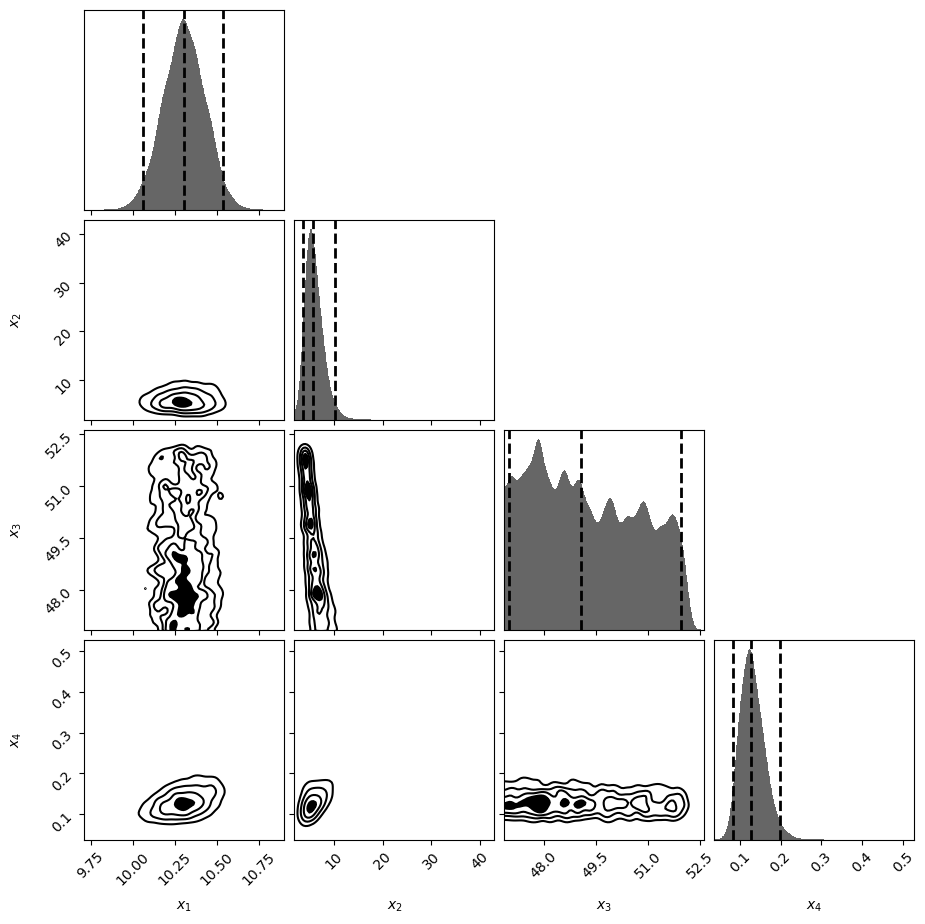

In [21]:
cfig, caxes = dyplot.cornerplot(sresults)

In [22]:
from dynesty import utils as dyfunc


# Extract sampling results.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights


evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 3.791271999783917e-29
68% parameter credible regions are:
 [[10.181413834250792, 10.431820556257817], [4.254613545345136, 7.5198319190246306], [47.599144989865124, 51.07156571031996], [0.10255402306778555, 0.15979502493082517]]

Mean and covariance of parameters are: [10.3063447   5.89901262 49.26963449  0.13170854]
[[ 1.50659520e-02  1.47680258e-02 -2.68408143e-03  1.46768931e-03]
 [ 1.47680258e-02  3.07908456e+00 -1.81987215e+00  2.95186005e-02]
 [-2.68408143e-03 -1.81987215e+00  2.27175253e+00 -2.29630957e-03]
 [ 1.46768931e-03  2.95186005e-02 -2.29630957e-03  8.56395842e-04]]
